In [3]:
import csv
import json
from datetime import datetime
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Task 1: Read CSV file
def read_csv_file(file_path):
    with open(file_path, newline='', encoding='utf-8') as csvfile:
        reader = csv.DictReader(csvfile)
        return list(reader)

# Debugging: Print column names in the CSV file
csv_file = "acw_user_data.csv"
rows = read_csv_file(csv_file)
print("CSV Headers:", rows[0].keys())

CSV Headers: dict_keys(['Address Street', 'Address City', 'Address Postcode', 'Age (Years)', 'Distance Commuted to Work (Km)', 'Employer Company', 'Credit Card Start Date', 'Credit Card Expiry Date', 'Credit Card Number', 'Credit Card CVV', 'Dependants', 'First Name', 'Bank IBAN', 'Last Name', 'Marital Status', 'Yearly Pension (Dollar)', 'Retired', 'Yearly Salary (Dollar)', 'Sex', 'Vehicle Make', 'Vehicle Model', 'Vehicle Year', 'Vehicle Type'])


In [4]:
# Task 2: Convert flat structure to nested structure

dependants_key = 'Dependants'
first_name_key = 'First Name'
last_name_key = 'Last Name'
age_key = 'Age (Years)'
salary_key = 'Yearly Salary (Dollar)'
commute_key = 'Distance Commuted to Work (Km)'
employer_key = 'Employer Company'
retired_key = 'Retired'
vehicle_make_key = 'Vehicle Make'
vehicle_model_key = 'Vehicle Model'
vehicle_year_key = 'Vehicle Year'
vehicle_type_key = 'Vehicle Type'
cc_start_key = 'Credit Card Start Date'
cc_end_key = 'Credit Card Expiry Date'
cc_number_key = 'Credit Card Number'
cc_security_key = 'Credit Card CVV'
cc_iban_key = 'Bank IBAN'
address_street_key = 'Address Street'
address_city_key = 'Address City'
address_postcode_key = 'Address Postcode'

def process_data(rows):
    processed_data = []
    problematic_rows = []
    
    for idx, row in enumerate(rows):
        if not row.get(dependants_key, '').strip():
            row[dependants_key] = '0'  # Replace empty values with 0
            problematic_rows.append(idx)
        
        person = {
            "first_name": row[first_name_key],
            "last_name": row[last_name_key],
            "age": int(row[age_key]),
            "dependants": int(row[dependants_key]),
            "vehicle": {
                "make": row[vehicle_make_key],
                "model": row[vehicle_model_key],
                "year": int(row[vehicle_year_key]),
                "type": row[vehicle_type_key]
            },
            "credit_card": {
                "start_date": row[cc_start_key],
                "end_date": row[cc_end_key],
                "number": row[cc_number_key],
                "security_code": row[cc_security_key],
                "IBAN": row[cc_iban_key]
            },
            "address": {
                "street": row[address_street_key],
                "city": row[address_city_key],
                "postcode": row[address_postcode_key]
            },
            "retired": row[retired_key].lower() == 'true',
            "employer": row[employer_key],
            "salary": float(row[salary_key]),
            "commute_km": float(row[commute_key])
        }
        processed_data.append(person)
    
    return processed_data, problematic_rows

In [5]:
# Task 4 & 5: Write processed data to JSON files
def write_json_file(filename, data):
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=4)

In [6]:
# Task 6: Filter credit card records with >10 year validity
def is_credit_card_invalid(start_date, end_date):
    start = datetime.strptime(start_date, "%m/%y")
    end = datetime.strptime(end_date, "%m/%y")
    return (end.year - start.year) > 10

In [7]:
# Task 7: Calculate Salary-Commute metric
def calculate_salary_commute(data):
    for person in data:
        commute = max(person["commute_km"], 1)
        person["salary_commute"] = person["salary"] / commute
    return sorted(data, key=lambda x: x["salary_commute"])

# Process CSV data
processed_data, problematic_rows = process_data(rows)

# Separate into employed and retired
employed = [p for p in processed_data if p['employer']]
retired = [p for p in processed_data if p['retired']]

# Filter invalid credit cards
invalid_cc = [p for p in processed_data if is_credit_card_invalid(p['credit_card']['start_date'], p['credit_card']['end_date'])]

# Compute salary-commute metric and sort
processed_sorted = calculate_salary_commute(processed_data)

# Write JSON outputs
write_json_file("processed.json", processed_data)
write_json_file("retired.json", retired)
write_json_file("employed.json", employed)
write_json_file("remove_ccard.json", invalid_cc)
write_json_file("commute.json", processed_sorted)

# Print problematic rows
print("Problematic rows for dependants:", problematic_rows)

Problematic rows for dependants: [21, 109, 179, 205, 270, 272, 274, 358, 460, 468, 579, 636, 679, 725, 822, 865, 917, 931, 983]


In [8]:
# Data Visualization using Pandas & Seaborn
# Load CSV into DataFrame
df = pd.read_csv(csv_file)

In [9]:
# Calculate Mean Salary and Median Age
mean_salary = df[salary_key].mean()
median_age = df[age_key].median()
print(f"Mean Salary: {mean_salary}")
print(f"Median Age: {median_age}")

Mean Salary: 57814.078
Median Age: 54.0


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


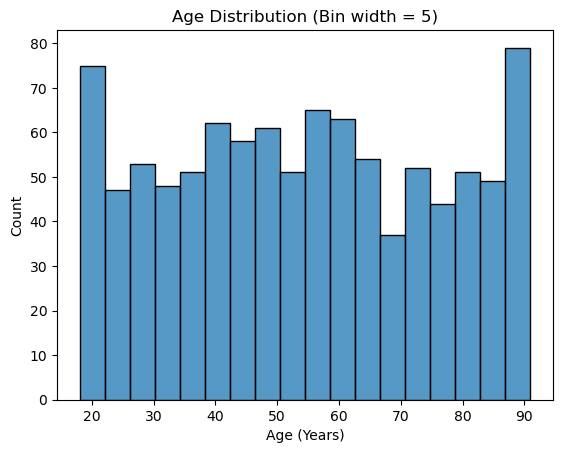

In [10]:
# Univariate plots
sns.histplot(df[age_key], bins=int(df[age_key].max()/5))
plt.title("Age Distribution (Bin width = 5)")
plt.savefig("age_distribution.png")
plt.show()

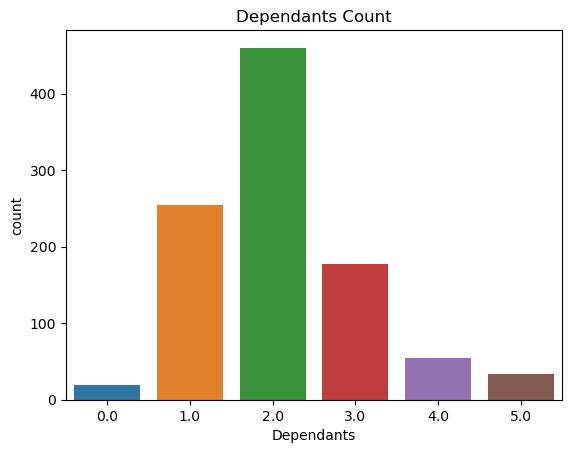

In [11]:
sns.countplot(x=df[dependants_key].fillna(0))
plt.title("Dependants Count")
plt.savefig("dependants_count.png")
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


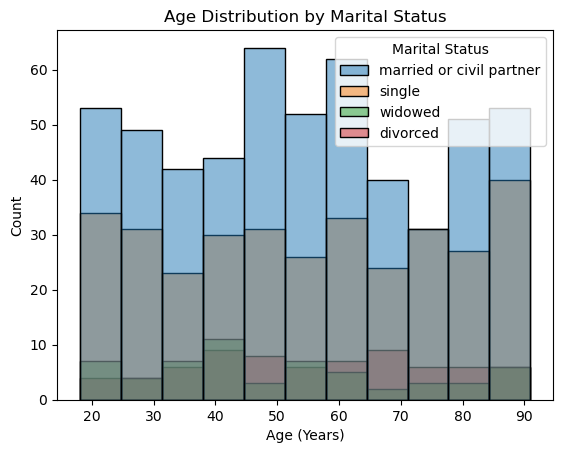

In [12]:
sns.histplot(df, x=age_key, hue="Marital Status")
plt.title("Age Distribution by Marital Status")
plt.savefig("age_marital_status.png")
plt.show()

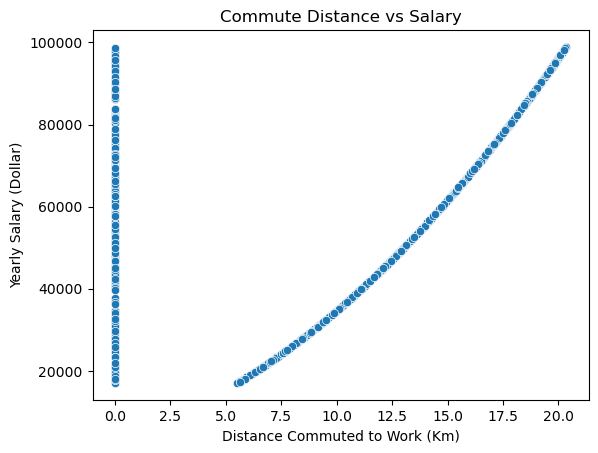

In [13]:
# Multivariate plots
sns.scatterplot(x=df[commute_key], y=df[salary_key])
plt.title("Commute Distance vs Salary")
plt.savefig("commute_vs_salary.png")
plt.show()

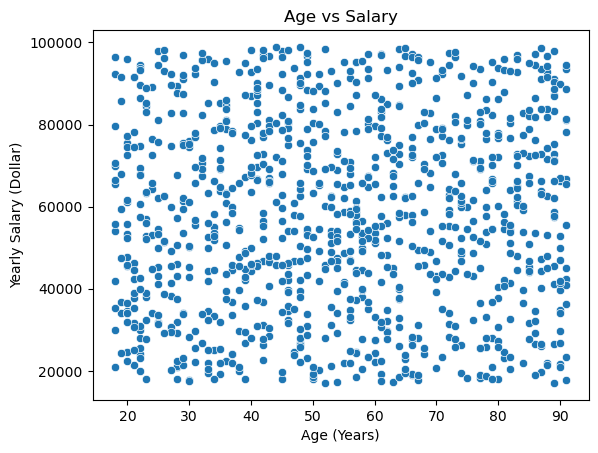

In [14]:
sns.scatterplot(x=df[age_key], y=df[salary_key])
plt.title("Age vs Salary")
plt.savefig("age_vs_salary.png")
plt.show()

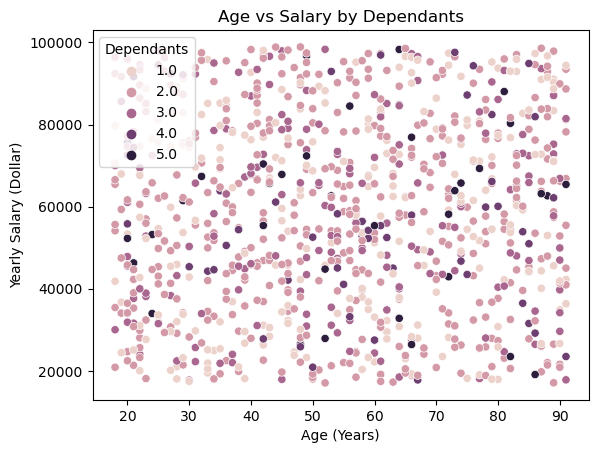

In [15]:
sns.scatterplot(x=df[age_key], y=df[salary_key], hue=df[dependants_key])
plt.title("Age vs Salary by Dependants")
plt.savefig("age_salary_dependants.png")
plt.show()